- 172651 - Abdilatif Ramadhan
- 189723 - Eleanor Linda Opolo
- 191252 - Adam Etyang

In [27]:
'''
q1: Here we initialised the Airoplane Crash Dataset

'''

import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "Airplane_Crashes_and_Fatalities_Since_1908.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "saurograndi/airplane-crashes-since-1908",
  file_path,
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'airplane-crashes-since-1908' dataset.
First 5 records:          Date   Time                            Location  \
0  09/17/1908  17:18                 Fort Myer, Virginia   
1  07/12/1912  06:30             AtlantiCity, New Jersey   
2  08/06/1913    NaN  Victoria, British Columbia, Canada   
3  09/09/1913  18:30                  Over the North Sea   
4  10/17/1913  10:30          Near Johannisthal, Germany   

                 Operator Flight #          Route                    Type  \
0    Military - U.S. Army      NaN  Demonstration        Wright Flyer III   
1    Military - U.S. Navy      NaN    Test flight               Dirigible   
2                 Private        -            NaN        Curtiss seaplane   
3  Military - German Navy      NaN            NaN  Zeppelin L-1 (airship)   
4  Military - German Navy      NaN            NaN  Zeppelin L-2 (airship)   

  Registration cn/In  Aboard  Fatalities  Ground  \
0          NaN     1     

In [28]:
'''
Q2: Here we determined the number of rows and columns in the dataset

'''

rows , columns = df.shape
print(f'The number of rows are {rows}, while the number of columns are {columns}')

The number of rows are 5268, while the number of columns are 13


In [29]:
'''
Q3: Here we displayed the last 75 rows of the dataset

'''
last_75 = df.tail(75)
print(last_75)


            Date   Time                                           Location  \
5193  03/15/2008  08:15                                     Nbagu, Nigeria   
5194  04/03/2008  11:00                                     Lawa, Suriname   
5195  04/09/2008  23:27                                Bundeena, Australia   
5196  04/11/2008  22:15                                 Chrisinau, Moldova   
5197  04/15/2008  14:30                                        Goma, Congo   
...          ...    ...                                                ...   
5263  05/20/2009  06:30                             Near Madiun, Indonesia   
5264  05/26/2009    NaN                  Near Isiro, DemocratiRepubliCongo   
5265  06/01/2009  00:15  AtlantiOcean, 570 miles northeast of Natal, Br...   
5266  06/07/2009  08:30       Near Port Hope Simpson, Newfoundland, Canada   
5267  06/08/2009    NaN                  State of Arunachal Pradesh, India   

                             Operator Flight #  \
5193        T

In [30]:
'''
Q4:

'''

'\nQ4:\n\n'

In [31]:
'''
Q5: Here we created the new dataframe with the required columns

'''
fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']].copy()


In [32]:
'''
Q6: Here we got the date with the highest number of fatalities
    by looking up in the date column against the row with the highest fatalities

'''
fatality_locations.loc[
    fatality_locations['Fatalities'].idxmax(),
    'Date'
]

'03/27/1977'

In [33]:
'''
Q7: Here we got the rows with fatalities as 0

'''
fatality_locations[['Aboard','Fatalities']]
no_fatalities = fatality_locations[
    fatality_locations['Fatalities'] == 0
]
print(len(no_fatalities))

58


In [34]:
'''
Q8: Here we split the location column to get the state/country and region columns
    by spliting against the first comma

'''
fatality_locations[['Region', 'State/Country']] = (
    fatality_locations['Location'].str.split(',', n=1, expand=True)
)

In [35]:
'''
Q9: Here we ordered the dataframe by the number of fatalities and got the top 100

'''
top_100 = fatality_locations.sort_values(
    'Fatalities',
    ascending=False
).head(100)
print(top_100)

            Date                                    Location  Aboard  \
2963  03/27/1977                    Tenerife, Canary Islands   644.0   
3568  08/12/1985       Mt. Osutaka, near Ueno Village, Japan   524.0   
4455  11/12/1996                    Near Charkhidadri, India   349.0   
2726  03/03/1974                   Near Ermenonville, France   346.0   
3562  06/23/1985     AtlantiOcean, 110 miles West of Ireland   329.0   
...          ...                                         ...     ...   
4852  04/15/2002                          Busan, South Korea   166.0   
3198  01/21/1980  Elburz Mtns., near Laskarak, Markazi, Iran   128.0   
1701  12/16/1960          Staten Island / Brooklyn, New York   128.0   
5108  07/09/2006                             Irkutsk, Russia   203.0   
1433  06/30/1956                       Grand Canyon, Arizona   128.0   

      Fatalities                    Region                  State/Country  
2963       583.0                  Tenerife                 

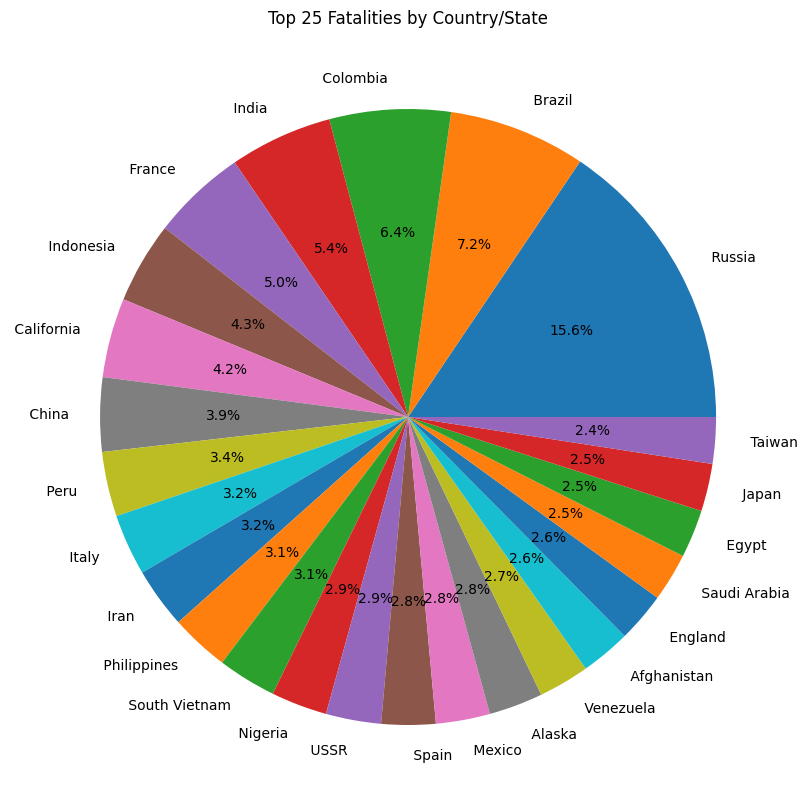

In [36]:
'''
Q10: Here we first grouped the grouped by country then sorted to get the top 25
      countries with the highest number of fatalities then drew the pie chart

'''
import matplotlib.pyplot as plt

ordered = fatality_locations.groupby('State/Country')['Fatalities'].sum().sort_values(ascending=False)
top_25 = ordered.head(25)


plt.figure(figsize=(10, 10))

plt.pie(
    top_25,
    labels=top_25.index,
    autopct='%1.1f%%'
)

plt.title('Top 25 Fatalities by Country/State')
plt.show()